# Regression, part a - Mikaela

In [ ]:
import pandas as pd

file_path = "student_lifestyle_dataset_full..csv" 
df = pd.read_csv(file_path)

numeric_df = df.select_dtypes(include=['float64', 'int64'])
categorical_df = df.select_dtypes(include=['object'])

ranges = numeric_df.max() - numeric_df.min()
std_devs = numeric_df.std()
means = numeric_df.mean()

stats_summary = pd.DataFrame({
    "Min": numeric_df.min(),
    "Max": numeric_df.max(),
    "Range": ranges,
    "Mean": means,
    "Standard Deviation": std_devs
})

print("=== Range and Standard Deviation of Numeric Attributes ===")
print(stats_summary)

print("\n=== Frequency counts of Categorical Attributes ===")
for col in categorical_df.columns:
    print(f"\n{col}:")
    counts = categorical_df[col].value_counts()
    print(dict(counts))

=== Range and Standard Deviation of Numeric Attributes ===
                                 Min     Max   Range         Mean  \
Student_ID                       1.0  2000.0  1999.0  1000.500000   
Study_Hours_Per_Day              5.0    10.0     5.0     7.475800   
Extracurricular_Hours_Per_Day    0.0     4.0     4.0     1.990100   
Sleep_Hours_Per_Day              5.0    10.0     5.0     7.501250   
Social_Hours_Per_Day             0.0     6.0     6.0     2.704550   
Physical_Activity_Hours_Per_Day  0.0    13.0    13.0     4.328300   
Grades                           5.6    10.0     4.4     7.789825   

                                 Standard Deviation  
Student_ID                               577.494589  
Study_Hours_Per_Day                        1.423888  
Extracurricular_Hours_Per_Day              1.155855  
Sleep_Hours_Per_Day                        1.460949  
Social_Hours_Per_Day                       1.688514  
Physical_Activity_Hours_Per_Day            2.514110  
Grades    

Best λ:  3.3033702702702707


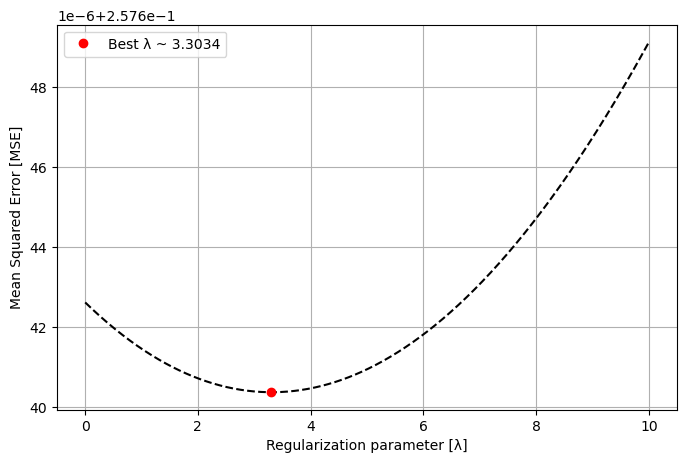


Coefficients: 
Study_Hours              :  0.475
Extracurricular_Hours    : -0.080
Sleep_Hours              : -0.089
Social_Hours             : -0.080
Physical_Activity_Hours  : -0.127
Gender                   : -0.009
Stress_Level             :  0.002
Intercept:  7.7898249999999996


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Project02 - Part A - Linear Regression 

df = pd.read_csv('student_lifestyle_dataset_full..csv')

df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Stress_Level'] = df['Stress_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})

X = df[['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day',
'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Gender', 'Stress_Level']].values
y = df['Grades'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ridge Regression with cross validation to find best λ
lambdas = np.linspace(0.0001, 10, 1000)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
mse_scores = []

for lam in lambdas:
    fold_errors = []
    for train_idx, test_idx in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = Ridge(alpha=lam)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        fold_errors.append(mean_squared_error(y_test, y_pred))
    mse_scores.append(np.mean(fold_errors))

best_lambda = lambdas[np.argmin(mse_scores)]
print('Best λ: ', best_lambda)

plt.figure(figsize=(8,5))
plt.plot(lambdas, mse_scores, 'k--')
plt.plot([best_lambda],[min(mse_scores)], 'ro', label='Best λ ~ {:.4f}'.format(best_lambda))
plt.xlabel('Regularization parameter [λ]')
plt.ylabel('Mean Squared Error [MSE]')
plt.grid(True) ; plt.legend()
plt.savefig('project02_partA2.png')
plt.show()

best_model = Ridge(alpha=best_lambda)
best_model.fit(X_scaled, y)

feature_names = ['Study_Hours', 'Extracurricular_Hours', 'Sleep_Hours',
                 'Social_Hours', 'Physical_Activity_Hours', 'Gender', 'Stress_Level']

print('\nCoefficients: ')
for name, coef in zip(feature_names, best_model.coef_):
    print(f"{name:25s}: {coef: .3f}")

print('Intercept: ', best_model.intercept_)


# Regression, part b - Denisa

We start by loading the cleaned dataset from the first project.

In [ ]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import torch
from sklearn import model_selection
from sklearn.linear_model import Ridge
import scipy.stats as st


In [ ]:
# Load dataset
df = pd.read_csv('/Volumes/MASTER/Year1/ML/ml-project/student_lifestyle_dataset..csv')

# Perform cleaning steps from project 1
df = df.drop(['Student_ID'], axis=1)
df = df[df['Physical_Activity_Hours_Per_Day'] < 11]

# Drop the discrete values for regression
df = df.drop(['Stress_Level', 'Gender'], axis=1)
df.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Grades
0,6.9,3.8,8.7,2.8,1.8,7.48
1,5.3,3.5,8.0,4.2,3.0,6.88
2,5.1,3.9,9.2,1.2,4.6,6.68
3,6.5,2.1,7.2,1.7,6.5,7.20
4,8.1,0.6,6.5,2.2,6.6,8.78


For regression, we will analyze how well the study, extracurricular, sleep, social and physical activity hours per day predict their grades.

We define X as the matrix containing the continuous values Study_Hours_Per_Day, Extracurricular_Hours_Per_Day, Sleep_Hours_Per_Day, Social_Hours_Per_Day and Physical_Activity_Hours_Per_Day.

In [ ]:
X = df.drop(['Grades'], axis=1).values

We define y as the Grades column.

In [ ]:
y = df['Grades'].values

In [ ]:
N, M = X.shape

*Implement two-level cross-validation (see algorithm 6 of the lecture notes). We will use
2-level cross-validation to compare the models with K1 = K2 = 10 folds2. As a baseline
model, we will apply a linear regression model with no features, i.e. it computes the mean
of y on the training data, and use this value to predict y on the test data*

*Make sure you can fit an ANN model to the data. As complexity-controlling parameter
for the ANN, we will use the number of hidden units h. Based on a few test-runs, select
a reasonable range of values for h (which should include h = 1), and describe the range of
values you will use for h and λ.*

Using the exercise 8, we modified the setup_storage_for_experiment to include the ANN.

In [ ]:
def setup_storage_for_experiment(K_outer, K_inner, num_lambdas, num_hidden_units):
    # Setup storage for the optimal hyperparameters found from the inner CV
    optimal_lambdas = np.empty(K_outer)
    optimal_hidden_units = np.empty(K_outer)

    # Setup storage for model coefficients and errors for each experiment in all inner folds
    ws_inner = np.empty((M + 1, K_outer, K_inner, num_lambdas))
    ridge_train_errors_inner = np.empty((K_outer, K_inner, num_lambdas))
    ridge_test_errors_inner = np.empty((K_outer, K_inner, num_lambdas))
    ann_train_errors_inner = np.empty((K_outer, K_inner, num_hidden_units))
    ann_test_errors_inner = np.empty((K_outer, K_inner, num_hidden_units))

    # Setup storage for model coefficients for each experiment in all outer folds
    ws_outer = {
        'regularized': np.empty((M + 1, K_outer))
    }
    # Setup storage for errors as a dictionary
    errors_outer = {
        'train': {
            'baseline': np.empty((K_outer, 1)), 
            'regularized': np.empty((K_outer, 1)),
            'ann': np.empty((K_outer, 1))
        },
        'test': {
            'baseline': np.empty((K_outer, 1)), 
            'regularized': np.empty((K_outer, 1)),
            'ann': np.empty((K_outer, 1))
        }
    }
    return optimal_lambdas, optimal_hidden_units, ws_inner, ridge_train_errors_inner, ridge_test_errors_inner, ann_train_errors_inner, ann_test_errors_inner, ws_outer, errors_outer

We defined the ANN model to work with.

In [ ]:
def get_model(input_dim, hidden_unit, output_dim):
    return torch.nn.Sequential(
        torch.nn.Linear(in_features=input_dim, out_features=hidden_unit, bias=True),     # Input layer
        torch.nn.Tanh(),                                                                 # Activation function
        torch.nn.Linear(in_features=hidden_unit, out_features=output_dim, bias=True),    # Output layer
    )

Using solutions from exercise 8 and 9, we have added inside the inner loop a code snippet to train ANN models with different hidden units. We have used standarization as suggested in the project 1 feedback.

In [ ]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)

# Values of regularization parameter lambda to test in the inner loop
lambdas = np.linspace(3, 5, 40)

# Hidden units for ANN
hidden_units = [7, 8]
lr = 1e-3
n_epochs = 1000

# Setup storage for the experiment
K_outer = 10
K_inner = 10
optimal_lambdas, optimal_hidden_units, ws_inner, ridge_train_errors_inner, ridge_test_errors_inner, ann_train_errors_inner, ann_test_errors_inner, ws_outer, errors_outer = setup_storage_for_experiment(K_outer, K_inner, len(lambdas), len(hidden_units))

# Create 10 fold splits
CV_outer = KFold(K_outer, shuffle=True, random_state=42)
CV_inner = KFold(K_inner, shuffle=True, random_state=42)

# Run two-layer cross-validation
for outer_fold_idx, (outer_train_index, outer_test_index) in enumerate(CV_outer.split(X, y)):
    
    # Extract training and test set for the current outer CV fold
    X_train_outer, y_train_outer = X[outer_train_index], y[outer_train_index]
    X_test_outer, y_test_outer = X[outer_test_index], y[outer_test_index]

    for inner_fold_idx, (inner_train_index, inner_test_index) in enumerate(CV_inner.split(X_train_outer, y_train_outer)):

        # Extract training and validation set for current inner CV fold
        X_train_inner, y_train_inner = X_train_outer[inner_train_index], y_train_outer[inner_train_index]
        X_test_inner, y_test_inner = X_train_outer[inner_test_index], y_train_outer[inner_test_index]

        # Compute the mean and standard deviation of the inner training data split, then standardize training and test sets
        mu_inner = np.mean(X_train_inner, axis=0)
        sigma_inner = np.std(X_train_inner, axis=0)
        
        # Standardize the inner training set and validation set
        X_train_inner_std = (X_train_inner - mu_inner) / sigma_inner
        X_test_inner_std = (X_test_inner - mu_inner) / sigma_inner

        # RIDGE REGRESSION
        # Loop over all values of lambda
        for lambda_idx, regularization_strength in enumerate(lambdas):
            # Create and fit the model
            lr_model = Ridge(alpha=regularization_strength)
            lr_model.fit(X_train_inner_std, y_train_inner)

            # Store the model coefficients for each value of lambda in the inner folds
            ws_inner[:, outer_fold_idx, inner_fold_idx, lambda_idx] = [lr_model.intercept_] + lr_model.coef_.flatten().tolist()

            # Compute and store the training and validation error
            ridge_train_errors_inner[outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean((y_train_inner - lr_model.predict(X_train_inner_std))**2, axis=0)
            ridge_test_errors_inner[outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean((y_test_inner - lr_model.predict(X_test_inner_std))**2, axis=0)
    
        # ANN
        X_train_inner_tensor = torch.tensor(X_train_inner_std, dtype=torch.float32)
        y_train_inner_tensor = torch.tensor(y_train_inner, dtype=torch.float32).view(-1, 1)
        X_test_inner_tensor = torch.tensor(X_test_inner_std, dtype=torch.float32)
        y_test_inner_tensor = torch.tensor(y_test_inner, dtype=torch.float32).view(-1, 1)

        for hidden_unit_idx, hidden_unit in enumerate(hidden_units):
            # Define a model with a specific number of hidden units
            ann_model = get_model(input_dim=M, hidden_unit=hidden_unit, output_dim=1)
            criterion = torch.nn.MSELoss()
            optimizer = torch.optim.SGD(params=ann_model.parameters(), lr=lr)
            
            for epoch in range(n_epochs):
                ann_model.train()
                outputs = ann_model(X_train_inner_tensor)
                loss = criterion(outputs, y_train_inner_tensor)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Compute the final train and validation loss
            with torch.no_grad():
                ann_model.eval()
                train_outputs = ann_model(X_train_inner_tensor)
                val_outputs = ann_model(X_test_inner_tensor)
                train_loss = criterion(train_outputs, y_train_inner_tensor)
                val_loss = criterion(val_outputs, y_test_inner_tensor)
                
                # Store in the arrays
                ann_train_errors_inner[outer_fold_idx, inner_fold_idx, hidden_unit_idx] = train_loss.item()
                ann_test_errors_inner[outer_fold_idx, inner_fold_idx, hidden_unit_idx] = val_loss.item()


    # Determine the optimal value of lambda that gives the lowest test error on average from the inner folds
    optimal_lambda_idx = np.argmin(np.mean(ridge_test_errors_inner[outer_fold_idx], axis=0))
    optimal_lambda = lambdas[optimal_lambda_idx]
    
    # Store the optimal regularization strength for the current outer fold
    optimal_lambdas[outer_fold_idx] = optimal_lambda

    # Determine the optimal number of hidden units
    avg_val_errors = np.mean(ann_test_errors_inner[outer_fold_idx], axis=0)
    optimal_hidden_unit_idx = np.argmin(avg_val_errors)
    optimal_hidden_unit = hidden_units[optimal_hidden_unit_idx]
    optimal_hidden_units[outer_fold_idx] = optimal_hidden_unit

    # Compute the mean and standard deviation of the outer training data split
    mu_outer = np.mean(X_train_outer, axis=0)
    sigma_outer = np.std(X_train_outer, axis=0)

    # Standardize the outer training set and test set
    X_train_outer_std = (X_train_outer - mu_outer) / sigma_outer
    X_test_outer_std = (X_test_outer - mu_outer) / sigma_outer

    # 1. REGULARIZED LINEAR REGRESSION
    optimal_lr_model = Ridge(alpha=optimal_lambda)
    optimal_lr_model.fit(X_train_outer_std, y_train_outer)
    ws_outer['regularized'][:, outer_fold_idx] = [optimal_lr_model.intercept_] + optimal_lr_model.coef_.flatten().tolist()
    errors_outer['train']['regularized'][outer_fold_idx] = np.mean((y_train_outer - optimal_lr_model.predict(X_train_outer_std))**2, axis=0)
    errors_outer['test']['regularized'][outer_fold_idx] = np.mean((y_test_outer - optimal_lr_model.predict(X_test_outer_std))**2, axis=0)

    # 2. BASELINE (NO FEATURES)
    # Compute mean of training data
    y_train_mean = np.mean(y_train_outer)
    
    # Predict mean for all samples
    y_train_pred_baseline = np.full(len(y_train_outer), y_train_mean)
    y_test_pred_baseline = np.full(len(y_test_outer), y_train_mean)
    
    # Compute errors
    errors_outer['train']['baseline'][outer_fold_idx] = np.mean((y_train_outer - y_train_pred_baseline)**2)
    errors_outer['test']['baseline'][outer_fold_idx] = np.mean((y_test_outer - y_test_pred_baseline)**2)

    # 3. ANN
    # Convert to torch tensors
    X_train_outer_tensor = torch.tensor(X_train_outer_std, dtype=torch.float32)
    y_train_outer_tensor = torch.tensor(y_train_outer, dtype=torch.float32).view(-1, 1)
    X_test_outer_tensor = torch.tensor(X_test_outer_std, dtype=torch.float32)
    y_test_outer_tensor = torch.tensor(y_test_outer, dtype=torch.float32).view(-1, 1)

    optimal_ann_model = get_model(input_dim=M, hidden_unit=int(optimal_hidden_unit), output_dim=1)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.SGD(params=optimal_ann_model.parameters(), lr=lr)
    
    for epoch in range(n_epochs):
        optimal_ann_model.train()
        outputs = optimal_ann_model(X_train_outer_tensor)
        loss = criterion(outputs, y_train_outer_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate ANN
    with torch.no_grad():
        optimal_ann_model.eval()
        train_outputs = optimal_ann_model(X_train_outer_tensor)
        test_outputs = optimal_ann_model(X_test_outer_tensor)
        errors_outer['train']['ann'][outer_fold_idx] = criterion(train_outputs, y_train_outer_tensor).item()
        errors_outer['test']['ann'][outer_fold_idx] = criterion(test_outputs, y_test_outer_tensor).item()

# Print results
print(f"\nOptimal regularization strengths per fold: {optimal_lambdas}")
print(f"Optimal hidden units per fold: {optimal_hidden_units}")


Optimal regularization strengths per fold: [3.35897436 3.76923077 4.58974359 4.12820513 4.07692308 3.
 5.         4.74358974 3.         5.        ]
Optimal hidden units per fold: [8. 8. 7. 7. 8. 8. 7. 8. 7. 8.]


In the testing phase we tried various intervals for lambdas and hidden units.

Hidden units values and the optimal hidden units per fold: 
* [1, 2, 5, 10] > [10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
* [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] > [ 9.  9.  8. 10.  9.  7. 11.  8. 10. 10.]
* [7, 8, 9, 10, 11] > [10.  7.  8.  8. 11.  7. 10.  8.  8. 10.]
* [7, 8, 10] > [10.  7. 10.  8. 10.  8.  7.  7.  7.  8.]
* [7, 8] > [8. 8. 7. 7. 8. 8. 7. 8. 7. 8.]

Lambda values and the optimal lambda per fold:
* 10 ** -5 > 10 ** 8 > [ 1.  1.  1.  1.  1.  1. 10.  1.  1. 10.]
* 10 ** -1 -> 10 ** 2 > [4.12462638 4.12462638 4.12462638 4.12462638 4.12462638 2.42446202
 7.01703829 4.12462638 2.42446202 4.12462638]
* 1 -> 10 > [3.45510729 3.45510729 4.92388263 4.12462638 4.12462638 2.89426612
 7.01703829 4.92388263 2.89426612 5.87801607]
* 2 -> 6 > [3.37931034 3.79310345 4.62068966 4.06896552 4.06896552 2.96551724 6. 4.75862069 2.68965517 5.5862069 ]
* 3 -> 5 > [3.35897436 3.76923077 4.58974359 4.12820513 4.07692308 3. 5. 4.74358974 3. 5.]


In [ ]:
# Create a results table
results_table = pd.DataFrame({
    'Outer Fold': np.arange(1, K_outer + 1),
    'Optimal Lambda': optimal_lambdas,
    'Optimal Hidden Units': optimal_hidden_units.astype(int),
    'Baseline Test Error': errors_outer['test']['baseline'].flatten(),
    'Regularized Test Error': errors_outer['test']['regularized'].flatten(),
    'ANN Test Error': errors_outer['test']['ann'].flatten()
})

# Display the table
print("\n" + "="*100)
print("TWO-LEVEL CROSS-VALIDATION RESULTS")
print("="*100)
print(results_table.to_string(index=False))

# Calculate mean
print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)
summary_stats = pd.DataFrame({
    'Model': ['Baseline', 'Regularized', 'ANN'],
    'Mean Test Error': [
        errors_outer['test']['baseline'].mean(),
        errors_outer['test']['regularized'].mean(),
        errors_outer['test']['ann'].mean()
    ]
})
print(summary_stats.to_string(index=False))


TWO-LEVEL CROSS-VALIDATION RESULTS
 Outer Fold  Optimal Lambda  Optimal Hidden Units  Baseline Test Error  Regularized Test Error  ANN Test Error
          1        3.358974                     8             0.545593                0.317271        0.321492
          2        3.769231                     8             0.565115                0.262859        0.282088
          3        4.589744                     7             0.583031                0.269921        0.290781
          4        4.128205                     7             0.554766                0.244693        0.262074
          5        4.076923                     8             0.559984                0.257265        0.265366
          6        3.000000                     8             0.569823                0.236963        0.237524
          7        5.000000                     7             0.582204                0.250396        0.274291
          8        4.743590                     8             0.476979      

*Statistically evaluate if there is a significant performance difference between the fitted ANN, linear regression model and baseline using the methods described in chapter 11. These comparisons will be made pairwise (ANN vs. linear regression; ANN vs. baseline; linear regression vs. baseline*

We will perform the statistical evaluation following *setup I (11.3): Use the paired t-test described in 11.3.4*. Since we have the test errors for each fold stored in errors_outer['test'], we'll use these errors directly for our statistical comparisons.

In [ ]:
# Extract test errors from each fold for all three models
ann_errors = errors_outer['test']['ann'].flatten()
ridge_errors = errors_outer['test']['regularized'].flatten()
baseline_errors = errors_outer['test']['baseline'].flatten()

In [ ]:
def confidence_interval_comparison(errors_A, errors_B, alpha=0.05):
    z = errors_A - errors_B
    z_hat = np.mean(z)
    
    n = len(errors_A)
    nu = n - 1  # degrees of freedom
    
    sem = np.sqrt(sum(((z - z_hat)**2) / (n * nu)))
    CI = st.t.interval(1 - alpha, df=nu, loc=z_hat, scale=sem)
    
    t_stat = -np.abs(np.mean(z)) / st.sem(z)
    p_value = 2 * st.t.cdf(t_stat, df=nu)  # p-value
    
    return z_hat, CI, p_value

We defined the alpha.

In [ ]:
alpha = 0.05

#### ANN vs linear regression

In [ ]:
z_hat, CI, p_value = confidence_interval_comparison(ann_errors, ridge_errors, alpha=alpha)
print(f"Difference in loss between ANN and regularized linear regression: \nz_hat: {z_hat:.4f}, \nCI: [{CI[0]:.4f}, {CI[1]:.4f}], \np-value: {p_value}")

Difference in loss between ANN and regularized linear regression: 
z_hat: 0.0139, 
CI: [0.0083, 0.0196], 
p-value: 0.0003548140483215036


#### ANN vs baseline

In [ ]:
z_hat, CI, p_value = confidence_interval_comparison(ann_errors, baseline_errors, alpha=alpha)
print(f"Difference in loss between ANN and baseline: \nz_hat: {z_hat:.4f}, \nCI: [{CI[0]:.4f}, {CI[1]:.4f}], \np-value: {p_value}")

Difference in loss between ANN and baseline: 
z_hat: -0.2841, 
CI: [-0.3128, -0.2553], 
p-value: 3.429676917906452e-09


#### Linear regression vs baseline

In [ ]:
z_hat, CI, p_value = confidence_interval_comparison(ridge_errors, baseline_errors, alpha=alpha)
print(f"Difference in loss between regularized linear regression and baseline: \nz_hat: {z_hat:.4f}, \nCI: [{CI[0]:.4f}, {CI[1]:.4f}], \np-value: {p_value}")

Difference in loss between regularized linear regression and baseline: 
z_hat: -0.2980, 
CI: [-0.3273, -0.2687], 
p-value: 2.6421801065728376e-09


LLM use: I have used an LLM to help me format the table for the TWO-LEVEL CROSS-VALIDATION RESULTS.

# Classification - Syeda

**Classification**\
Classify stress levels into low, moderate, high\
Dataset to be used: df2, but would need dropping of gender --> df_class


In [ ]:
import numpy as np
from sklearn.model_selection import LeaveOneOut, KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
from tqdm import tqdm       #for progress bar

In [ ]:
#load data
df2.head()
df_class = df2.drop(columns = 'Gender')
df_class.head()
# sns.pairplot(df_class, size=3)

#split into features and labels
X = df_class.drop(columns='Stress_Level')        #features
y = df_class['Stress_Level']                     #labels

assert X.shape == (2000,6)
assert y.shape == (2000,)

**Baseline**\
A moodel that ignores input and uses majority voting to choose label.\
2-level CV fold.\
Split data into training and test sets.\

In [ ]:
#initialise leave-one-out cross validation, save it as CV_loo
CV_loo = LeaveOneOut()  

accuracies_bl = []

#loop through the folds
for fold, (train_index, test_index) in tqdm(enumerate(CV_loo.split(X)), 
                                            desc="Cross validation fold (baseline)", 
                                            total=CV_loo.get_n_splits(X)):
    #data split
    X_train, y_train = X.iloc[train_index,:], y[train_index]    #iloc: integer-location based indexing 
    X_test, y_test = X.iloc[test_index, :], y[test_index]

    #apply model 
    model = DummyClassifier(strategy = 'most_frequent')
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_bl.append(acc)

#results for baseline model  
#results for multinomail logistic regression 
print(f"Mean accuracy for baseline model: {np.mean(accuracies_bl):.4f}")
print(f"Mean error for baseline model: {1-np.mean(accuracies_bl):.4f}")

Cross validation fold (baseline): 100%|██████████| 2000/2000 [00:01<00:00, 1522.47it/s]

Mean accuracy for baseline model: 0.5145
Mean error for baseline model: 0.4855


**Multinomial logistic regression**\
Regularization parameter λ≥, using softmax activation for our multi-class problem.\
(Assumptions for logistic regression: independent observations, binary dependet variables, linear relationship
between independent variables and log odds, no outliers, large sample size)

In [ ]:
#initialise leave-one-out cross validation, save it as CV_loo
CV_loo_lr = LeaveOneOut()  

accuracies_lr = []

#loop through the folds
for fold, (train_index, test_index) in tqdm(enumerate(CV_loo_lr.split(X)), 
                                            desc="Cross validation fold (multinormial logistic regression)", 
                                            total=CV_loo_lr.get_n_splits(X)):
    #data split
    X_train, y_train = X.iloc[train_index,:], y[train_index]    #iloc: integer-location based indexing 
    X_test, y_test = X.iloc[test_index, :], y[test_index]


    #apply model 
    model = LogisticRegression(
                                # multi_class = 'multinomial',   #deprecated variable, default is multinomialf or n>2
                               max_iter = 1000,
                               solver = 'lbfgs', 
                               C = 1.0)     #C is inverse of regularization strength (lambda), default is 1
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_lr.append(acc)

#results for multinomail logistic regression 
print(f"Mean accuracy for logistic regression: {np.mean(accuracies_lr):.4f}")
print(f"Mean error for logistic regression: {1-np.mean(accuracies_lr):.4f}")

Cross validation fold (multinormial logistic regression): 100%|██████████| 2000/2000 [00:36<00:00, 54.69it/s]

Mean accuracy for logistic regression: 0.8275
Mean error for logistic regression: 0.1725


**Method 2: KNN**\
Complexity controlling parameter k= 1,2...\
Evaluate performance of models with varying k-values using 2-fold leave-one-out cross-validation.\
Split data into training and test sets for each fold.\

In [ ]:
#maximum number of neighbors
K_neighbors = [1, 3, 7, 9, 11, 15,31]

#initialise leave-one-out cross validation, save it as CV_loo
CV_loo_knn = LeaveOneOut()  

#accuracies for each k
accuracies_knn = {k: [] for k in K_neighbors}

#loop through the folds
for fold, (train_index, test_index) in tqdm(enumerate(CV_loo_knn.split(X)), 
                                            desc="Cross validation fold (KNN)", 
                                            total=CV_loo_knn.get_n_splits(X)):
    #data split
    X_train, y_train = X.iloc[train_index,:], y[train_index]    #iloc: integer-location based indexing 
    X_test, y_test = X.iloc[test_index, :], y[test_index]

    for k in K_neighbors:
        
        #apply model 
        model = KNeighborsClassifier(n_neighbors = k)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        
        accuracies_knn[k].append(acc)

#results for KNN for each k  
for k in K_neighbors:
    print(f"KNN with k={k}: mean accuracy: {np.mean(accuracies_knn[k]):.4f}, mean error: {1-np.mean(accuracies_knn[k]):.4f}")

Cross validation fold (KNN): 100%|██████████| 2000/2000 [00:21<00:00, 93.05it/s]

KNN with k=1: mean accuracy: 0.8915, mean error: 0.1085
KNN with k=3: mean accuracy: 0.9020, mean error: 0.0980
KNN with k=7: mean accuracy: 0.9145, mean error: 0.0855
KNN with k=9: mean accuracy: 0.9180, mean error: 0.0820
KNN with k=11: mean accuracy: 0.9115, mean error: 0.0885
KNN with k=15: mean accuracy: 0.9090, mean error: 0.0910
KNN with k=31: mean accuracy: 0.9115, mean error: 0.0885


**Comparing the three models: Baseline, Multinomal Logistic Regression, KNN**\
2-fold cross-validation will be used, with outer 10-fold stratified CV and inner 5-fold stratified CV.\
In the 5 inner folds, the parameters will be tuned (k or KNN, $\lambda$ for logistic).\


In [ ]:
from sklearn.metrics import accuracy_score

def two_level_cv_classification(X, y, outer_folds=10, inner_folds=5):
    
    #initialise outer stratified k-fold CV with 10 folds, inner with 5
    CV_outer = StratifiedKFold(outer_folds, shuffle = True)
    CV_inner = StratifiedKFold(inner_folds, shuffle = True)
    
    #for McNemar's test later:
    all_preds = {
        "logreg": np.zeros(len(y)),
        "knn": np.zeros(len(y)),
        "baseline": np.zeros(len(y)),
        "true": np.zeros(len(y)),
    }
    
    #complexity parameters for logistic, KNN respectively
    lambda_values = [0.01, 0.1, 1, 10, 100]
    k_values = [1, 3, 7, 9, 11, 15, 31]
    
    #to store results in each outer fold
    results1 = []
    
    #outer loop
    for i, (outer_train_idx, outer_test_idx) in enumerate(CV_outer.split(X, y)):       
        
        #split data into train and test sets
        X_train_outer, X_test_outer = X.iloc[outer_train_idx], X.iloc[outer_test_idx]
        y_train_outer, y_test_outer = y.iloc[outer_train_idx], y.iloc[outer_test_idx]
    
        #-----------multinomial logreg inner CV----------------
        avg_errors_lr = []
        for lam in lambda_values:
            inner_errors_lr = []
            for inner_train_idx, inner_test_idx in CV_inner.split(X_train_outer, y_train_outer):
                X_train_inner, X_test_inner = X_train_outer.iloc[inner_train_idx], X_train_outer.iloc[inner_test_idx]  
                y_train_inner, y_test_inner = y_train_outer.iloc[inner_train_idx], y_train_outer.iloc[inner_test_idx]  
                
                model = LogisticRegression(max_iter = 1000,solver = 'lbfgs', C = 1/lam)
                model.fit(X_train_inner, y_train_inner)
                
                y_pred_inner = model.predict(X_test_inner)
                inner_errors_lr.append(1 - accuracy_score(y_test_inner, y_pred_inner))
            avg_errors_lr.append(np.mean(inner_errors_lr))
        best_lambda = lambda_values[np.argmin(avg_errors_lr)]
        
        #-----------KNN inner CV----------------
        avg_errors_knn = []
        for k in k_values:
            inner_errors_knn = []
            for inner_train_idx, inner_test_idx in CV_inner.split(X_train_outer, y_train_outer):
                X_train_inner, X_test_inner = X_train_outer.iloc[inner_train_idx], X_train_outer.iloc[inner_test_idx]  
                y_train_inner, y_test_inner = y_train_outer.iloc[inner_train_idx], y_train_outer.iloc[inner_test_idx]  
                
                model = KNeighborsClassifier(n_neighbors = k)
                model.fit(X_train_inner, y_train_inner)
                
                y_pred_inner = model.predict(X_test_inner)
                inner_errors_knn.append(1 - accuracy_score(y_test_inner, y_pred_inner))
            avg_errors_knn.append(np.mean(inner_errors_knn))
        best_k = k_values[np.argmin(avg_errors_knn)]
        
        
        #-------baseline model has nothing to loop over since no complexity parameter-----
        
        #statistical evaluation of outer splits
        
        #logreg
        model_lr = LogisticRegression(max_iter = 1000,solver = 'lbfgs', C = 1/best_lambda)      
        model_lr.fit(X_train_outer, y_train_outer)
        y_pred_lr = model_lr.predict(X_test_outer)
        E_lr = 1 - accuracy_score(y_test_outer, y_pred_lr)
        
        #knn
        model_knn = KNeighborsClassifier(n_neighbors = best_k)                                  
        model_knn.fit(X_train_outer, y_train_outer)
        y_pred_knn = model_knn.predict(X_test_outer)
        E_knn = 1 - accuracy_score(y_test_outer, y_pred_knn)
        
        #baseline
        model_bl = DummyClassifier(strategy = 'most_frequent')                                  
        model_bl.fit(X_train_outer, y_train_outer)
        y_pred_bl = model_bl.predict(X_test_outer)
        E_bl = 1 - accuracy_score(y_test_outer, y_pred_bl)
        
        #store predictions for outer test indices (for McNemar's test)
        all_preds['logreg'][outer_test_idx] = y_pred_lr
        all_preds['knn'][outer_test_idx] = y_pred_knn
        all_preds['baseline'][outer_test_idx] = y_pred_bl
        all_preds['true'][outer_test_idx] = y_test_outer
        
        #store results 
        results1.append({
            "Outer fold (i)": i + 1,
            "h*_i (KNN)": best_k,
            "E_test (KNN)": round(E_knn, 3),
            "λ*_i (LogReg)": best_lambda,
            "E_test (LogReg)": round(E_lr, 3),
            "E_test (Baseline)": round(E_bl, 3)
        })

    return pd.DataFrame(results1), all_preds

In [ ]:
results_df, all_preds = two_level_cv_classification(X, y)
print(results_df)
print("\n")
print(all_preds)

   Outer fold (i)  h*_i (KNN)  E_test (KNN)  λ*_i (LogReg)  E_test (LogReg)  \
0               1          15         0.090           1.00            0.165   
1               2          11         0.090          10.00            0.185   
2               3           7         0.065          10.00            0.180   
3               4           3         0.105           0.01            0.195   
4               5          11         0.115           0.10            0.190   
5               6          15         0.070           0.10            0.200   
6               7           7         0.105           0.01            0.170   
7               8          15         0.075           1.00            0.145   
8               9          11         0.095           1.00            0.185   
9              10           9         0.100           0.01            0.155   

   E_test (Baseline)  
0              0.490  
1              0.485  
2              0.485  
3              0.485  
4              

**Statistical Evalaution of the three models**\
Using Setup I: McNemar's test: check whether models behave differently or not, on the same test samples.\
Use the all_preds variable in CV function to get statistical results.\
p-values and confidence intervals for three pairwise tests.\
Baseline vs. KNN, Baseline vs. Logreg, KNN vs Logreg.

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

#get labels from each model, as well as true labels
y_true = np.array(all_preds["true"])
y_lr = np.array(all_preds["logreg"])
y_knn = np.array(all_preds["knn"])
y_bl = np.array(all_preds["baseline"])

def mcnemar_test(y_true, pred1, pred2, model1, model2):
    
    #compare whether results from both models equal or not
    a_correct = pred1 == y_true
    b_correct = pred2 == y_true
    
    #values for contingency table
    n01 = np.sum(~a_correct & b_correct)        #no. of cases where model1 wrong, model2 right
    n10 = np.sum(a_correct & ~b_correct)        #no. of cases where model1 right, model2 wrong
    
    #contingency table, carry out mcnemar test
    table = [[0, n01],[n10, 0]]
    mcnemar_result = mcnemar(table, exact=False, correction=True)
    
    #confidence intervals to see difference in accuracies
    n_total = n01 + n10
    if n_total > 0:
        diff = (n10 - n01)/n_total
        se = np.sqrt(1/n_total)               #standard error
        ci_low = diff - (1.96 * se)
        ci_high = diff + (1.96 * se)
    else:
        diff, ci_low, ci_high = 0, 0, 0
    
    print(f"{model1} vs {model2}:")
    print(f"diff = {diff:.4f}, p-value = {mcnemar_result.pvalue:.3e}, 95% CI: [{ci_low:.4f},{ci_high:.4f}]")
    
#pairwise comparisons
mcnemar_test(y_true, y_lr, y_knn, "Logreg", "KNN")
mcnemar_test(y_true, y_bl, y_lr, "Baseline", "Logreg")
mcnemar_test(y_true, y_bl, y_knn, "Baseline", "KNN")

Logreg vs KNN:
diff = -0.4433, p-value = 3.916e-18, 95% CI: [-0.5428,-0.3438]
Baseline vs Logreg:
diff = -0.6894, p-value = 3.332e-94, 95% CI: [-0.7549,-0.6239]
Baseline vs KNN:
diff = -0.9293, p-value = 4.482e-161, 95% CI: [-0.9966,-0.8621]


**Train logistic regression model using suitable $\lambda$ = 0.01**\
This value was chosen since it appeared most often in the 2-level CV.\
Check which features are more relevant by finding their coefficients; the higher the coefficient, the higher that feature was weighted.

In [ ]:
suitable_lambda = 0.01
final_lr_model = LogisticRegression(max_iter = 1000,solver = 'lbfgs', C = 1/suitable_lambda)
final_lr_model.fit(X, y)

#find coefficients of each feature
coefficients = pd.DataFrame(
    final_lr_model.coef_,
    columns = X.columns, 
    index = [f"Class {stress_level_class}" for stress_level_class in  final_lr_model.classes_]
)

print(coefficients)

         Study_Hours_Per_Day  Extracurricular_Hours_Per_Day  \
Class 0            -4.649550                       1.000170   
Class 1             1.529938                      -0.352726   
Class 2             3.119612                      -0.647445   

         Sleep_Hours_Per_Day  Social_Hours_Per_Day  \
Class 0             2.092662              0.877780   
Class 1            -0.347067             -0.288810   
Class 2            -1.745595             -0.588969   

         Physical_Activity_Hours_Per_Day    Grades  
Class 0                         0.896792  0.331666  
Class 1                        -0.324818 -0.245299  
Class 2                        -0.571974 -0.086367  
